<a href="https://colab.research.google.com/github/Shalapais/WpfApp1/blob/master/digits_dataset_30022026_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# КТ "Прохождение Теста Тьюринга (CAPTCHA)"

**Цель**: исследовать набор рукописных цифр и написать ИНС для их распознавания с вероятностью не менее 90%



In [ ]:
#импорт функции загрузки датасета цифр из библиотеки
from sklearn.datasets import load_digits

digits = load_digits() #запишем датасет рукописных цифр в переменную digits

dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [ ]:
print(len(digits['images']))

print(digits['images'][49]) #изображение №50

1797
[[ 0.  0.  1. 15. 13.  1.  0.  0.]
 [ 0.  0.  7. 16. 14.  8.  0.  0.]
 [ 0.  8. 12.  9.  2. 13.  2.  0.]
 [ 0.  7.  9.  1.  0.  6.  6.  0.]
 [ 0.  5.  9.  0.  0.  3.  9.  0.]
 [ 0.  0. 15.  2.  0.  8. 12.  0.]
 [ 0.  0.  9. 15. 13. 16.  6.  0.]
 [ 0.  0.  0. 13. 14.  8.  0.  0.]]


Графический вывод цифры №50


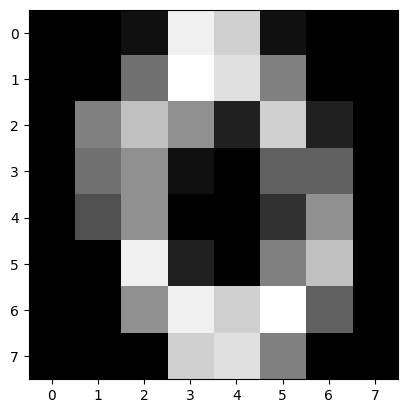

Целевое значение для изображения
0


In [ ]:
print('Графический вывод цифры №50')

from matplotlib import pyplot as plt

plt.figure() #создаем графическое изображение
plt.imshow(digits['images'][49], cmap='gray')
plt.show()

print('Целевое значение для изображения')
print(digits['target'][49])

In [ ]:
import numpy as np
#Выберем набор векторов для обучения и истинных значений чисел

x = np.reshape(digits['images'],[len(digits['images']),64])
y = digits['target']

print(x[100])


[ 0.  0.  0.  2. 13.  0.  0.  0.  0.  0.  0.  8. 15.  0.  0.  0.  0.  0.
  5. 16.  5.  2.  0.  0.  0.  0. 15. 12.  1. 16.  4.  0.  0.  4. 16.  2.
  9. 16.  8.  0.  0.  0. 10. 14. 16. 16.  4.  0.  0.  0.  0.  0. 13.  8.
  0.  0.  0.  0.  0.  0. 13.  6.  0.  0.]


In [ ]:
print(10**64)

10000000000000000000000000000000000000000000000000000000000000000


In [ ]:
#Развернем двумерное изображение в вектор
#x это массив для обучения
x = digits['images'].reshape((len(digits['images']),64)) #x это вектор из 1797 элементов
#в которых 64 элемента
print(x[100])
#y это список целевых значений
y = digits['target']
print(y[100])

[ 0.  0.  0.  2. 13.  0.  0.  0.  0.  0.  0.  8. 15.  0.  0.  0.  0.  0.
  5. 16.  5.  2.  0.  0.  0.  0. 15. 12.  1. 16.  4.  0.  0.  4. 16.  2.
  9. 16.  8.  0.  0.  0. 10. 14. 16. 16.  4.  0.  0.  0.  0.  0. 13.  8.
  0.  0.  0.  0.  0.  0. 13.  6.  0.  0.]
4


In [ ]:
import numpy as np
print('max brightness value in digits array')
print(np.max(digits['images']))

max brightness value in digits array
16.0


In [ ]:
## Разделим набор данных на часть для обучения (train) и тестирования (test)
#Zipf
#Набор для обучения 70% данных, набор для тестирования 30%
#Найдем индекс для разделения набора на выборки
divider_index = int(len(x)*0.7)
x_train = x[:divider_index] #вектора для обучения
y_train = y[:divider_index]
x_test = x[divider_index:] #вектора дял проверки качества обучения
y_test = y[divider_index:]


In [ ]:
#Проектирование и обучение ИНС

from sklearn.neural_network import MLPClassifier

mpl = MLPClassifier(hidden_layer_sizes=(15,), #15 нейронов в скрытом слое
                    activation='logistic', #функция передачи сигнала
                    alpha=1e-4, #параметр "подстройки" 0.0001
                    solver='sgd', #stochastic gradient descent метод обучения
                    tol=1e-4, #допуск изменения значения функции потерь
                    learning_rate_init=0.1, #начальное значение настройки
                    random_state=42, #фиксируем случайное состояние
                    verbose=True #вывод диагностики
                   )



In [ ]:
#Обучение ИНС

mpl.fit(x_train,y_train)


Iteration 1, loss = 2.23520071
Iteration 2, loss = 1.84634036
Iteration 3, loss = 1.46119742
Iteration 4, loss = 1.13917509
Iteration 5, loss = 0.88741834
Iteration 6, loss = 0.68554887
Iteration 7, loss = 0.54376584
Iteration 8, loss = 0.44431139
Iteration 9, loss = 0.36934778
Iteration 10, loss = 0.31008325
Iteration 11, loss = 0.26991500
Iteration 12, loss = 0.25952895
Iteration 13, loss = 0.20716092
Iteration 14, loss = 0.18912621
Iteration 15, loss = 0.16944764
Iteration 16, loss = 0.15548202
Iteration 17, loss = 0.14374738
Iteration 18, loss = 0.13796700
Iteration 19, loss = 0.12199803
Iteration 20, loss = 0.11340121
Iteration 21, loss = 0.10913486
Iteration 22, loss = 0.10415368
Iteration 23, loss = 0.09311666
Iteration 24, loss = 0.09133075
Iteration 25, loss = 0.08714855
Iteration 26, loss = 0.08136548
Iteration 27, loss = 0.07976626
Iteration 28, loss = 0.07380836
Iteration 29, loss = 0.07175088
Iteration 30, loss = 0.06766549
Iteration 31, loss = 0.06447361
Iteration 32, los

MLPClassifier(activation='logistic', hidden_layer_sizes=(15,),
              learning_rate_init=0.1, random_state=42, solver='sgd',
              verbose=True)

In [ ]:
#Проверка качетсва обучения на произвольной цифре

index = 152
digit_predicted = mpl.predict((x_test[index],))
digit_true = y_test[index]
print('ИНС прочитала число',digit_predicted,'а число было',digit_true)


ИНС прочитала число [8] а число было 8


In [ ]:
#Вычисление точности распознавания

good = 0
bad = 0

for index in range(0,len(y_test)):
    digit_predicted = mpl.predict((x_test[index],))
    digit_true = y_test[index]
    if digit_predicted == digit_true:
        good = good + 1
    else:
        bad = bad + 1

accuracy = 100 * good/len(y_test)
print('Точность распознавания',accuracy,'%')


Точность распознавания 90.37037037037037 %


In [ ]:
help(MLPClassifier)

Help on class MLPClassifier in module sklearn.neural_network._multilayer_perceptron:

class MLPClassifier(sklearn.base.ClassifierMixin, BaseMultilayerPerceptron)
 |  MLPClassifier(hidden_layer_sizes=(100,), activation='relu', *, solver='adam', alpha=0.0001, batch_size='auto', learning_rate='constant', learning_rate_init=0.001, power_t=0.5, max_iter=200, shuffle=True, random_state=None, tol=0.0001, verbose=False, warm_start=False, momentum=0.9, nesterovs_momentum=True, early_stopping=False, validation_fraction=0.1, beta_1=0.9, beta_2=0.999, epsilon=1e-08, n_iter_no_change=10, max_fun=15000)
 |
 |  Multi-layer Perceptron classifier.
 |
 |  This model optimizes the log-loss function using LBFGS or stochastic
 |  gradient descent.
 |
 |  .. versionadded:: 0.18
 |
 |  Parameters
 |  ----------
 |  hidden_layer_sizes : array-like of shape(n_layers - 2,), default=(100,)
 |      The ith element represents the number of neurons in the ith
 |      hidden layer.
 |
 |  activation : {'identity', '

ASCII вывод матрицы несоответствий
[[50  0  0  0  0  0  2  0  1  0]
 [ 0 45  0  1  3  0  0  0  0  4]
 [ 3  0 50  0  0  0  0  0  0  0]
 [ 0  0  1 42  0  2  0  3  5  0]
 [ 0  1  0  0 53  0  1  0  2  0]
 [ 0  0  0  0  0 52  1  0  2  1]
 [ 0  0  0  0  0  0 54  0  0  0]
 [ 0  1  0  0  1  1  0 48  0  3]
 [ 0  1  1  0  0  1  1  0 45  3]
 [ 1  0  0  2  0  1  0  1  1 49]]


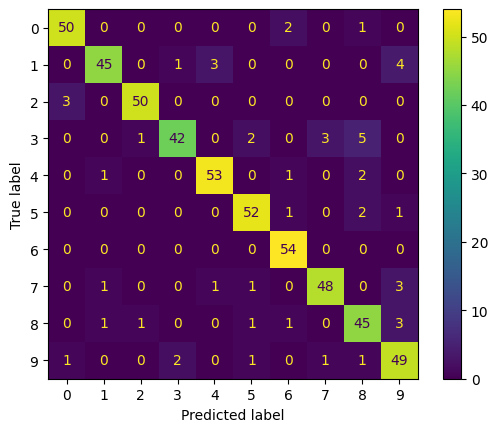

In [ ]:

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred = []

for i in x_test:
    y_pred.append(mpl.predict((i,)))

cm = confusion_matrix(y_test,y_pred)

print('ASCII вывод матрицы несоответствий')
print(cm)


cm_plot = ConfusionMatrixDisplay(cm) #создание объекта матрицы
cm_plot.plot() #вывод объекта

Открытие изображений
размерность изображения (100, 100, 4)
размерность изображения из набора обучения (8, 8)
Вывод изображения графически


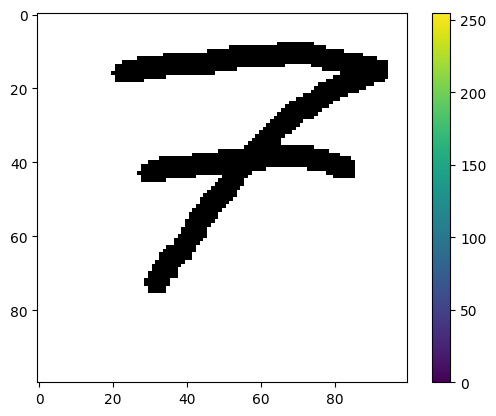

Вывод изображения из обучающего набора


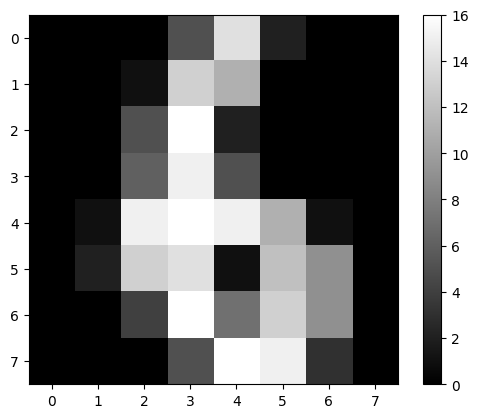

Сократим числ каналов до одного


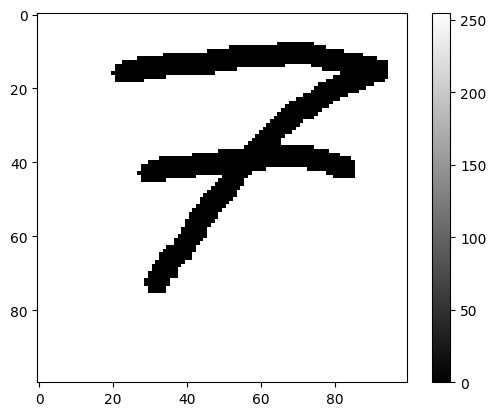

Уменьшаем размер изображения
Вывод изображения графически


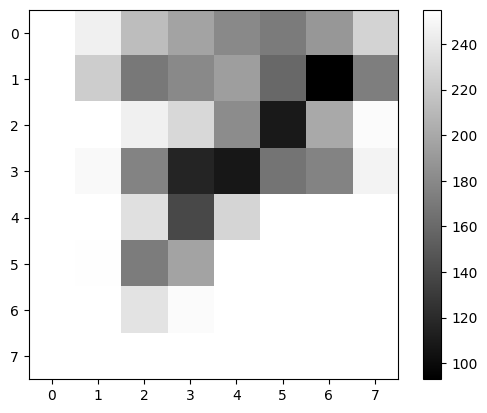

Уменьшим число спектральных градаций


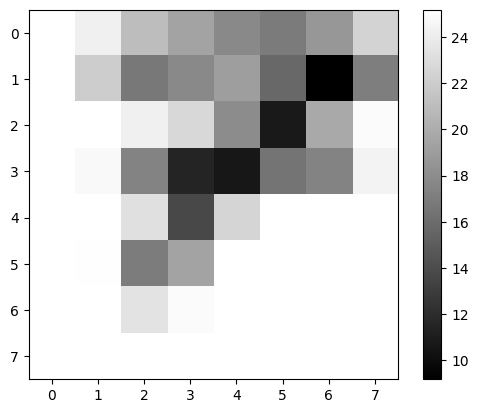

Попытка распознавания
[5]


In [ ]:
import imageio.v2 as io
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image


print('Открытие изображений')
img = io.imread('7.png')

print('размерность изображения',np.shape(img))

print('размерность изображения из набора обучения',np.shape(digits['images'][32]))

print ('Вывод изображения графически')
plt.imshow(img)
plt.colorbar()
plt.show()
print('Вывод изображения из обучающего набора')
plt.imshow(digits['images'][34],cmap='gray')
plt.colorbar()
plt.show()

print('Сократим числ каналов до одного')
img = img[:,:,0]
plt.imshow(img,cmap='gray')
plt.colorbar()
plt.show()

print ('Уменьшаем размер изображения')
img = Image.fromarray(img) #преобразовании матрицы изображения в формат PIL
img = img.resize((8,8),Image.BILINEAR)
print('Вывод изображения графически')
plt.imshow(img,cmap='gray')
plt.colorbar()
plt.show()
print('Уменьшим число спектральных градаций')
max_value = np.max(digits['images'][34]) #16
img = np.array(img,dtype='float') #из PIL в формат np.array
img = max_value * img / (np.max(img)-np.min(img))
plt.imshow(img,cmap='gray')
plt.colorbar()
plt.show()

print('Попытка распознавания')
predicted_number = mpl.predict(img.reshape([1,64]))
print(predicted_number)

In [ ]:
(324**2)*3

314928